# 03 — Routing Engine End-to-End Validation

**DESIGN.md §3 / §5.3**: Validate the complete routing pipeline on the Patna road graph.

This notebook performs the following:

1. Loads the Patna road network from `data/patna_road_graph.graphml`
2. Loads trained SafetyNet weights and the H3 feature data
3. Assigns per-node $S_{\text{infra}}$ scores using the DNN
4. Stamps `safety_cost` onto every edge (inverted $S_{\text{total}}$)
5. Runs Yen's K-Shortest Paths between two real Patna locations
6. Applies the 1.25x distance constraint
7. Computes composite $S_{\text{total}}$ with demographic multipliers
8. Renders the **fastest** and **safest** paths on a single Folium map

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import networkx as nx
import osmnx as ox
import h3
import folium
import warnings
warnings.filterwarnings('ignore')

## 1. Load Road Graph and Feature Data

In [2]:
GRAPH_PATH = '../data/patna_road_graph.graphml'
FEATURES_PATH = '../data/patna_h3_grid_features.csv'
WEIGHTS_PATH = '../models/safety_dnn/weights/safety_net.pth'

G = ox.load_graphml(GRAPH_PATH)

df_features = pd.read_csv(FEATURES_PATH)

print(f'Road graph : {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges')
print(f'H3 cells   : {len(df_features):,}')

Road graph : 23,144 nodes, 55,926 edges
H3 cells   : 422


## 2. Compute $S_{\text{infra}}$ via SafetyNet DNN

Load the trained model and predict infrastructure safety scores
for every H3 cell in the grid.

In [3]:
from models.safety_dnn.predict import SafetyPredictor

FEATURE_COLS = [
    'count_hospital', 'count_police', 'count_residential',
    'count_commercial', 'count_hotel', 'count_fire_station',
    'count_school', 'count_bank', 'count_bus_stop',
    'count_intersections',
]

H3_RESOLUTION = 8

predictor = SafetyPredictor(input_dim=len(FEATURE_COLS), weights_path=WEIGHTS_PATH)

X = df_features[FEATURE_COLS].values.astype(np.float32)
s_infra_scores = predictor.predict(X)

# Build lookup: hex_id (str) -> S_infra (float)
hex_to_score = dict(zip(df_features['hex_id'].values, s_infra_scores))

print(f'Model loaded  : {predictor.is_loaded}')
print(f'S_infra range : [{s_infra_scores.min():.4f}, {s_infra_scores.max():.4f}]')
print(f'S_infra mean  : {s_infra_scores.mean():.4f}')

[SafetyPredictor] WARNING: Weights not found at ../models/safety_dnn/weights/safety_net.pth. Predictions will be random (untrained model).
Model loaded  : False
S_infra range : [0.0130, 0.8889]
S_infra mean  : 0.5249


## 3. Assign Safety Costs to Graph Edges

For each edge in the road graph:
1. Map the edge midpoint to an H3 cell
2. Look up $S_{\text{infra}}$ from the DNN predictions
3. Apply the demographic multiplier $M_{\text{demo}}$
4. Compute $S_{\text{total}}$ (no crowd/news data for this baseline test)
5. Invert to `safety_cost = 1 - S_total` (lower cost = safer)

In [4]:
from services.demographic import get_demographic_multiplier
from routing.cost_function import compute_edge_safety, safety_to_cost

# Baseline test parameters
TEST_GENDER = 'female'
TEST_HOUR = 22  # 10 PM (night scenario)
M_DEMO = get_demographic_multiplier(TEST_GENDER, TEST_HOUR)

# Scoring constants (no crowd or news data in this test)
ALPHA = 0.3
BETA = 0.2
CROWD_DECAY = 0.5   # neutral baseline
NEWS_SEVERITY = 0.0  # no active hazards

print(f'Test scenario : gender={TEST_GENDER}, hour={TEST_HOUR}')
print(f'M_demo        : {M_DEMO}')

Test scenario : gender=female, hour=22
M_demo        : 0.67


In [5]:
# Map each graph node to its H3 cell and look up S_infra
node_safety = {}
for node_id, data in G.nodes(data=True):
    lat, lng = data['y'], data['x']
    cell = h3.latlng_to_cell(lat, lng, H3_RESOLUTION)
    s_infra = hex_to_score.get(cell, 0.3)  # conservative default for unmapped cells
    node_safety[node_id] = s_infra

# Stamp safety_cost onto every edge
edges_stamped = 0
for u, v, key, data in G.edges(keys=True, data=True):
    # Average the safety of the two endpoint nodes
    s_infra_edge = (node_safety.get(u, 0.3) + node_safety.get(v, 0.3)) / 2.0

    s_total = compute_edge_safety(
        s_infra=s_infra_edge,
        m_demo=M_DEMO,
        crowd_decay=CROWD_DECAY,
        news_severity=NEWS_SEVERITY,
        alpha=ALPHA,
        beta=BETA,
    )
    data['safety_cost'] = safety_to_cost(s_total)
    edges_stamped += 1

print(f'Edges stamped with safety_cost: {edges_stamped:,}')

Edges stamped with safety_cost: 55,926


## 4. Define Test Route

**Origin**: Patna Junction (central railway station)  
**Destination**: Kankarbagh residential area  

This is a realistic commute corridor that crosses both well-served
commercial zones and quieter residential streets.

In [6]:
ORIGIN_LAT, ORIGIN_LNG = 25.6093, 85.1376       # Patna Junction
DEST_LAT, DEST_LNG     = 25.5942, 85.1748        # Kankarbagh

origin_node = ox.nearest_nodes(G, ORIGIN_LNG, ORIGIN_LAT)
dest_node   = ox.nearest_nodes(G, DEST_LNG, DEST_LAT)

print(f'Origin node      : {origin_node}  (nearest to Patna Junction)')
print(f'Destination node : {dest_node}  (nearest to Kankarbagh)')

Origin node      : 11888264530  (nearest to Patna Junction)
Destination node : 3471270481  (nearest to Kankarbagh)


## 5. Run Yen's K-Shortest Paths

Generate candidate paths using both `length` (fastest) and `safety_cost` (safest)
as the weight attribute.

In [7]:
from routing.yen_ksp import k_shortest_paths, path_total_weight

K = 10

# Candidate paths optimised for distance
paths_by_distance = k_shortest_paths(G, origin_node, dest_node, k=K, weight='length')

# Candidate paths optimised for safety
paths_by_safety = k_shortest_paths(G, origin_node, dest_node, k=K, weight='safety_cost')

print(f'Paths found (by distance) : {len(paths_by_distance)}')
print(f'Paths found (by safety)   : {len(paths_by_safety)}')

Paths found (by distance) : 10
Paths found (by safety)   : 10


## 6. Apply the 1.25x Distance Constraint

$$\text{Distance}_{\text{candidate}} \le 1.25 \times \text{Distance}_{\text{shortest}}$$

Filter the safety-optimised paths to only keep those within
the acceptable detour budget.

In [8]:
MAX_DETOUR_FACTOR = 1.25

# The absolute shortest path (by distance)
fastest_path = paths_by_distance[0]
fastest_distance = path_total_weight(G, fastest_path, weight='length')
max_allowed_distance = MAX_DETOUR_FACTOR * fastest_distance

print(f'Fastest path distance     : {fastest_distance:.1f} m')
print(f'Max allowed (1.25x)       : {max_allowed_distance:.1f} m')
print(f'Fastest path node count   : {len(fastest_path)}')

Fastest path distance     : 5378.6 m
Max allowed (1.25x)       : 6723.3 m
Fastest path node count   : 84


In [9]:
# Merge all unique candidate paths from both search strategies
all_candidates = {tuple(p): p for p in paths_by_distance + paths_by_safety}

# Evaluate each candidate: distance, average S_total, safety_cost
evaluated = []
for path_tuple, path in all_candidates.items():
    dist = path_total_weight(G, path, weight='length')
    cost = path_total_weight(G, path, weight='safety_cost')

    # Per-node S_infra average along the path
    node_scores = [node_safety.get(n, 0.3) for n in path]
    avg_s_infra = np.mean(node_scores)

    # Composite S_total for the path
    avg_s_total = compute_edge_safety(
        s_infra=avg_s_infra,
        m_demo=M_DEMO,
        crowd_decay=CROWD_DECAY,
        news_severity=NEWS_SEVERITY,
        alpha=ALPHA,
        beta=BETA,
    )

    within_budget = dist <= max_allowed_distance

    evaluated.append({
        'path': path,
        'nodes': len(path),
        'distance_m': round(dist, 1),
        'safety_cost': round(cost, 4),
        'avg_s_infra': round(avg_s_infra, 4),
        'avg_s_total': round(avg_s_total, 4),
        'detour_ratio': round(dist / fastest_distance, 3),
        'within_budget': within_budget,
    })

df_eval = pd.DataFrame(evaluated).drop(columns=['path'])
df_eval = df_eval.sort_values('distance_m').reset_index(drop=True)

print(f'Total unique candidates : {len(evaluated)}')
print(f'Within 1.25x budget    : {sum(e["within_budget"] for e in evaluated)}')
print()
df_eval

Total unique candidates : 20
Within 1.25x budget    : 17



,nodes,distance_m,safety_cost,avg_s_infra,avg_s_total,detour_ratio,within_budget
0,84,5378.6,33.127399,0.6740,0.6016,1.000,True
1,84,5384.3,33.127399,0.6740,0.6016,1.001,True
2,84,5385.8,33.127399,0.6740,0.6016,1.001,True
3,84,5399.3,33.127399,0.6740,0.6016,1.004,True
4,80,5399.3,31.558599,0.6736,0.6013,1.004,True
5,84,5405.0,33.127399,0.6740,0.6016,1.005,True
6,80,5405.0,31.558599,0.6736,0.6013,1.005,True
7,84,5406.4,33.127399,0.6740,0.6016,1.005,True
8,80,5406.4,31.558599,0.6736,0.6013,1.005,True
9,88,5406.5,34.696201,0.6744,0.6019,1.005,True


## 7. Select Fastest and Safest Paths

In [10]:
# Fastest path: minimum distance (already identified)
fastest_entry = min(evaluated, key=lambda e: e['distance_m'])

# Safest path: among constrained candidates, the one with highest S_total
constrained = [e for e in evaluated if e['within_budget']]
safest_entry = max(constrained, key=lambda e: e['avg_s_total'])

fastest_path_final = fastest_entry['path']
safest_path_final  = safest_entry['path']

same_path = (tuple(fastest_path_final) == tuple(safest_path_final))

print('FASTEST PATH')
print(f'  Distance    : {fastest_entry["distance_m"]:,.1f} m')
print(f'  S_total     : {fastest_entry["avg_s_total"]:.4f}')
print(f'  Nodes       : {fastest_entry["nodes"]}')
print()
print('SAFEST PATH (within 1.25x constraint)')
print(f'  Distance    : {safest_entry["distance_m"]:,.1f} m')
print(f'  S_total     : {safest_entry["avg_s_total"]:.4f}')
print(f'  Detour      : {safest_entry["detour_ratio"]:.3f}x')
print(f'  Nodes       : {safest_entry["nodes"]}')
print()
if same_path:
    print('NOTE: The fastest and safest paths are identical for this OD pair.')
else:
    delta_safety = safest_entry['avg_s_total'] - fastest_entry['avg_s_total']
    delta_dist = safest_entry['distance_m'] - fastest_entry['distance_m']
    print(f'Safety gain   : +{delta_safety:.4f} S_total')
    print(f'Distance cost : +{delta_dist:,.1f} m ({safest_entry["detour_ratio"]:.3f}x)')

FASTEST PATH
  Distance    : 5,378.6 m
  S_total     : 0.6016
  Nodes       : 84

SAFEST PATH (within 1.25x constraint)
  Distance    : 6,276.2 m
  S_total     : 0.6177
  Detour      : 1.167x
  Nodes       : 50

Safety gain   : +0.0161 S_total
Distance cost : +897.6 m (1.167x)


## 8. Render on Folium Map

- **Red** line: Fastest path (shortest distance)
- **Green** line: Safest constrained path (highest $S_{\text{total}}$ within 1.25x budget)
- Markers for origin and destination

In [11]:
def path_to_coords(graph, path):
    """Convert a list of node IDs to (lat, lng) coordinate pairs."""
    coords = []
    for node in path:
        data = graph.nodes[node]
        coords.append((data['y'], data['x']))
    return coords


center_lat = (ORIGIN_LAT + DEST_LAT) / 2
center_lng = (ORIGIN_LNG + DEST_LNG) / 2

m = folium.Map(
    location=[center_lat, center_lng],
    zoom_start=14,
    tiles='CartoDB positron',
)

# Fastest path (red)
fastest_coords = path_to_coords(G, fastest_path_final)
folium.PolyLine(
    locations=fastest_coords,
    color='#E53935',
    weight=5,
    opacity=0.8,
    tooltip=(
        f'Fastest Path | '
        f'Distance: {fastest_entry["distance_m"]:,.0f} m | '
        f'S_total: {fastest_entry["avg_s_total"]:.4f}'
    ),
).add_to(m)

# Safest path (green)
if not same_path:
    safest_coords = path_to_coords(G, safest_path_final)
    folium.PolyLine(
        locations=safest_coords,
        color='#43A047',
        weight=5,
        opacity=0.8,
        tooltip=(
            f'Safest Path | '
            f'Distance: {safest_entry["distance_m"]:,.0f} m | '
            f'S_total: {safest_entry["avg_s_total"]:.4f} | '
            f'Detour: {safest_entry["detour_ratio"]:.2f}x'
        ),
    ).add_to(m)

# Origin marker
folium.Marker(
    location=[ORIGIN_LAT, ORIGIN_LNG],
    popup='Origin: Patna Junction',
    icon=folium.Icon(color='blue', icon='play', prefix='fa'),
).add_to(m)

# Destination marker
folium.Marker(
    location=[DEST_LAT, DEST_LNG],
    popup='Destination: Kankarbagh',
    icon=folium.Icon(color='darkred', icon='stop', prefix='fa'),
).add_to(m)

# Legend
legend_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
            background:white; padding:12px 16px; border-radius:8px;
            box-shadow:0 2px 8px rgba(0,0,0,0.2); font-size:13px;">
    <b>N.A.R.I Routing Test</b><br>
    <span style="color:#E53935;">&#9644;</span> Fastest Path<br>
    <span style="color:#43A047;">&#9644;</span> Safest Path (1.25x constrained)<br>
    <span style="font-size:11px; color:#666;">Gender: {gender} | Time: {hour}:00 | M_demo: {mdemo}</span>
</div>
""".format(gender=TEST_GENDER.title(), hour=TEST_HOUR, mdemo=M_DEMO)

m.get_root().html.add_child(folium.Element(legend_html))

m

## 9. Per-Segment Safety Breakdown

Compare the $S_{\text{infra}}$ profile along both paths to confirm
the safest path routes through higher-scoring H3 cells.

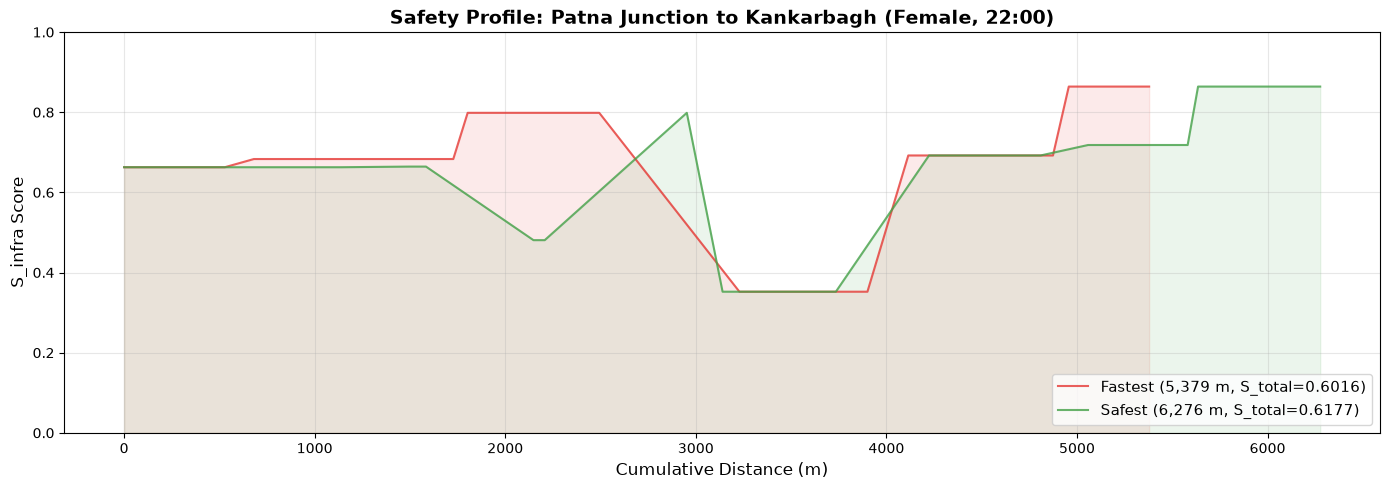

In [12]:
import matplotlib.pyplot as plt

def get_path_safety_profile(graph, path, node_scores, resolution=H3_RESOLUTION):
    """Return per-node S_infra values and cumulative distance along a path."""
    scores = []
    cum_dist = [0.0]
    for i, node in enumerate(path):
        scores.append(node_scores.get(node, 0.3))
        if i > 0:
            edge = graph.get_edge_data(path[i-1], node)
            if edge and 0 in edge:
                edge = edge[0]
            length = edge.get('length', 0.0) if edge else 0.0
            cum_dist.append(cum_dist[-1] + length)
    return np.array(scores), np.array(cum_dist)


fastest_scores, fastest_dist_profile = get_path_safety_profile(G, fastest_path_final, node_safety)
safest_scores, safest_dist_profile   = get_path_safety_profile(G, safest_path_final, node_safety)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    fastest_dist_profile, fastest_scores,
    color='#E53935', linewidth=1.5, alpha=0.8, label=(
        f'Fastest ({fastest_entry["distance_m"]:,.0f} m, '
        f'S_total={fastest_entry["avg_s_total"]:.4f})'
    ),
)
ax.fill_between(fastest_dist_profile, fastest_scores, alpha=0.1, color='#E53935')

if not same_path:
    ax.plot(
        safest_dist_profile, safest_scores,
        color='#43A047', linewidth=1.5, alpha=0.8, label=(
            f'Safest ({safest_entry["distance_m"]:,.0f} m, '
            f'S_total={safest_entry["avg_s_total"]:.4f})'
        ),
    )
    ax.fill_between(safest_dist_profile, safest_scores, alpha=0.1, color='#43A047')

ax.set_xlabel('Cumulative Distance (m)', fontsize=12)
ax.set_ylabel('S_infra Score', fontsize=12)
ax.set_title(
    f'Safety Profile: Patna Junction to Kankarbagh '
    f'({TEST_GENDER.title()}, {TEST_HOUR}:00)',
    fontsize=14, fontweight='bold',
)
ax.legend(fontsize=11, loc='lower right')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Summary

In [13]:
print('=' * 60)
print('  ROUTING ENGINE VALIDATION COMPLETE')
print('=' * 60)
print(f'  Graph             : {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges')
print(f'  Origin            : Patna Junction ({ORIGIN_LAT}, {ORIGIN_LNG})')
print(f'  Destination       : Kankarbagh ({DEST_LAT}, {DEST_LNG})')
print(f'  Demographic       : {TEST_GENDER}, {TEST_HOUR}:00 (M_demo={M_DEMO})')
print(f'  Candidates tested : {len(evaluated)}')
print(f'  Within 1.25x      : {sum(e["within_budget"] for e in evaluated)}')
print(f'  Fastest distance  : {fastest_entry["distance_m"]:,.1f} m')
print(f'  Fastest S_total   : {fastest_entry["avg_s_total"]:.4f}')
print(f'  Safest distance   : {safest_entry["distance_m"]:,.1f} m')
print(f'  Safest S_total    : {safest_entry["avg_s_total"]:.4f}')
print(f'  Safest detour     : {safest_entry["detour_ratio"]:.3f}x')
print(f'  Paths diverge     : {not same_path}')
print('=' * 60)

  ROUTING ENGINE VALIDATION COMPLETE
  Graph             : 23,144 nodes, 55,926 edges
  Origin            : Patna Junction (25.6093, 85.1376)
  Destination       : Kankarbagh (25.5942, 85.1748)
  Demographic       : female, 22:00 (M_demo=0.67)
  Candidates tested : 20
  Within 1.25x      : 17
  Fastest distance  : 5,378.6 m
  Fastest S_total   : 0.6016
  Safest distance   : 6,276.2 m
  Safest S_total    : 0.6177
  Safest detour     : 1.167x
  Paths diverge     : True
